# DataFest

**Group name:** The Defenders of Tomorrow

**Student names & numbers:**
* 
* 
* Seb van den Hoven - 101469


---

## 0. Iteration setup

**Import libraries**

In [11]:
# CODE CELL: import the necessary libraries for this iteration
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
import seaborn
import matplotlib.pyplot as plt
import seaborn as sns

**Load dataset(s)**

In [7]:
df = pd.read_csv("data\energie en broeikasgassen 1990-2024.csv")

<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\sidne\AppData\Local\Temp\ipykernel_7852\1794427163.py:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  df = pd.read_csv("data\energie en broeikasgassen 1990-2024.csv")


In [8]:
df.head()

,Jaar,Balanspost,Energiedrager,Waarde in PJ
0,1990,Winning,Totaal energiedragers,2542.1
1,1990,Winning,Aardoliegrondstoffen en producten,175.2
2,1990,Winning,Aardgas,2283.0
3,1990,Winning,Kernenergie,38.0
4,1990,Winning,Hernieuwbare energie,31.1


---

## 1. Business Understanding

### Business objective(s)


### Business success criteria



### Data mining goal(s)



### Data mining success criteria




---

## 2. Data Understanding

### Data exploration


In [9]:
print("First five rows of the dataset:")
display(df.head(10))

print("Dataset Information:")
df.info()

print("Description of the dataset:")
df.describe(include=['object'])

First five rows of the dataset:


,Jaar,Balanspost,Energiedrager,Waarde in PJ
0,1990,Winning,Totaal energiedragers,2542.1
1,1990,Winning,Aardoliegrondstoffen en producten,175.2
2,1990,Winning,Aardgas,2283.0
3,1990,Winning,Kernenergie,38.0
4,1990,Winning,Hernieuwbare energie,31.1
5,1990,Winning,Waterkracht,0.3
6,1990,Winning,Windenergie,0.2
7,1990,Winning,Zonne-energie,0.1
8,1990,Winning,Biomassa,30.5
9,1990,Winning,Overig,14.8


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Jaar           834 non-null    int64  
 1   Balanspost     834 non-null    str    
 2   Energiedrager  834 non-null    str    
 3   Waarde in PJ   834 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 26.2 KB
Description of the dataset:


C:\Users\sidne\AppData\Local\Temp\ipykernel_7852\110801766.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,Balanspost,Energiedrager
count,834,834
unique,3,14
top,Winning,Aardgas
freq,398,106


### Findings


### Visualizations and patterns


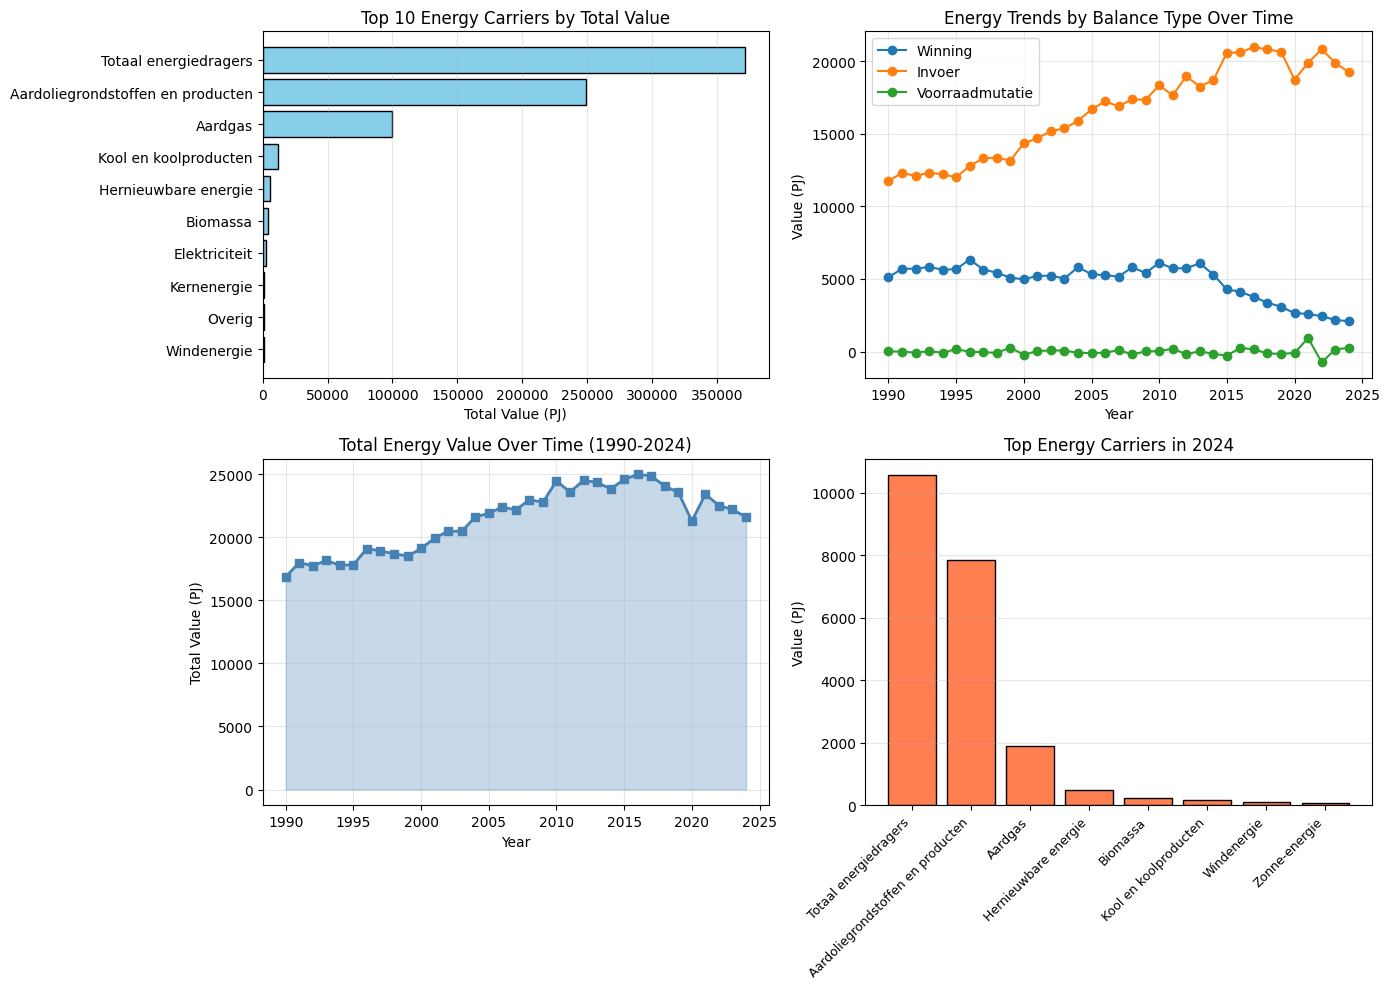

In [12]:
# Create visualizations for energy data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Energy value distribution by energy carrier
ax1 = axes[0, 0]
energy_by_carrier = df.groupby('Energiedrager')['Waarde in PJ'].sum().sort_values(ascending=True).tail(10)
ax1.barh(energy_by_carrier.index, energy_by_carrier.values, color='skyblue', edgecolor='black')
ax1.set_xlabel('Total Value (PJ)')
ax1.set_title('Top 10 Energy Carriers by Total Value')
ax1.grid(alpha=0.3, axis='x')

# 2. Energy value trends by balance type
ax2 = axes[0, 1]
balance_types = df['Balanspost'].unique()
for balance_type in balance_types:
    data = df[df['Balanspost'] == balance_type].groupby('Jaar')['Waarde in PJ'].sum()
    ax2.plot(data.index, data.values, label=balance_type, marker='o')
ax2.set_xlabel('Year')
ax2.set_ylabel('Value (PJ)')
ax2.set_title('Energy Trends by Balance Type Over Time')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Total energy value over years
ax3 = axes[1, 0]
yearly_total = df.groupby('Jaar')['Waarde in PJ'].sum()
ax3.plot(yearly_total.index, yearly_total.values, color='steelblue', marker='s', linewidth=2)
ax3.fill_between(yearly_total.index, yearly_total.values, alpha=0.3, color='steelblue')
ax3.set_xlabel('Year')
ax3.set_ylabel('Total Value (PJ)')
ax3.set_title('Total Energy Value Over Time (1990-2024)')
ax3.grid(alpha=0.3)

# 4. Energy carrier distribution comparison
ax4 = axes[1, 1]
latest_year = df['Jaar'].max()
latest_data = df[df['Jaar'] == latest_year].groupby('Energiedrager')['Waarde in PJ'].sum().sort_values(ascending=False).head(8)
ax4.bar(range(len(latest_data)), latest_data.values, color='coral', edgecolor='black')
ax4.set_xticks(range(len(latest_data)))
ax4.set_xticklabels(latest_data.index, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Value (PJ)')
ax4.set_title(f'Top Energy Carriers in {latest_year}')
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Data insights and data quality


In [13]:
print("=" * 80)
print("ANALYSIS: GUIDING QUESTIONS")
print("=" * 80)

# ============= QUESTION 1: When do different sources of renewable energy come online? =============
print("\n1. WHEN DO DIFFERENT RENEWABLE ENERGY SOURCES COME ONLINE?")
print("-" * 80)

renewable_sources = ['Hernieuwbare energie', 'Waterkracht', 'Windenergie', 'Zonne-energie', 'Biomassa']
renewable_data = df[df['Energiedrager'].isin(renewable_sources)].copy()

for source in renewable_sources:
    source_data = renewable_data[renewable_data['Energiedrager'] == source]
    if len(source_data) > 0:
        first_year = source_data['Jaar'].min()
        first_value = source_data[source_data['Jaar'] == first_year]['Waarde in PJ'].values
        if first_value[0] > 0:
            print(f"  • {source}: came online in {first_year} (initial value: {first_value[0]:.2f} PJ)")
        else:
            # Find first non-zero value
            first_nonzero = source_data[source_data['Waarde in PJ'] > 0]
            if len(first_nonzero) > 0:
                year = first_nonzero['Jaar'].min()
                val = first_nonzero[first_nonzero['Jaar'] == year]['Waarde in PJ'].values[0]
                print(f"  • {source}: first recorded value in {year} ({val:.2f} PJ)")

# ============= QUESTION 2: Greatest growth in renewable energy (past 10 years) =============
print("\n2. WHICH RENEWABLE SOURCES HAVE SEEN GREATEST GROWTH IN PAST 10 YEARS?")
print("-" * 80)

latest_year = df['Jaar'].max()
ten_years_ago = latest_year - 10

renewable_growth = []
for source in renewable_sources:
    source_data = renewable_data[renewable_data['Energiedrager'] == source]
    
    current = source_data[source_data['Jaar'] == latest_year]['Waarde in PJ'].sum()
    past = source_data[source_data['Jaar'] == ten_years_ago]['Waarde in PJ'].sum()
    
    if past > 0:
        growth_pct = ((current - past) / past) * 100
        growth_abs = current - past
        renewable_growth.append({
            'source': source,
            'past': past,
            'current': current,
            'growth_abs': growth_abs,
            'growth_pct': growth_pct
        })

renewable_growth_df = pd.DataFrame(renewable_growth).sort_values('growth_pct', ascending=False)
for idx, row in renewable_growth_df.iterrows():
    print(f"  • {row['source']}: {row['past']:.2f} PJ → {row['current']:.2f} PJ ({row['growth_pct']:+.1f}%, {row['growth_abs']:+.2f} PJ)")

# ============= QUESTION 3: Fossil fuel usage trends =============
print("\n3. HAS THE NETHERLANDS DECREASED FOSSIL FUEL USAGE?")
print("-" * 80)

fossil_fuels = ['Aardoliegrondstoffen en producten', 'Aardgas', 'Steenkool']
fossil_data = df[df['Energiedrager'].isin(fossil_fuels)].copy()

for fuel in fossil_fuels:
    fuel_data = fossil_data[fossil_data['Energiedrager'] == fuel]
    
    current = fuel_data[fuel_data['Jaar'] == latest_year]['Waarde in PJ'].sum()
    past = fuel_data[fuel_data['Jaar'] == ten_years_ago]['Waarde in PJ'].sum()
    
    if past > 0:
        change_pct = ((current - past) / past) * 100
        change_abs = current - past
        direction = "↓ DECREASED" if change_pct < 0 else "↑ INCREASED"
        print(f"  • {fuel}: {past:.2f} PJ → {current:.2f} PJ ({change_pct:+.1f}%) {direction}")

# Summary trend over full period
print("\n  FULL PERIOD ANALYSIS (1990-2024):")
fossil_1990 = fossil_data[fossil_data['Jaar'] == 1990]['Waarde in PJ'].sum()
fossil_2024 = fossil_data[fossil_data['Jaar'] == 2024]['Waarde in PJ'].sum()
fossil_change = ((fossil_2024 - fossil_1990) / fossil_1990) * 100
print(f"    Total fossil fuel usage 1990: {fossil_1990:.2f} PJ")
print(f"    Total fossil fuel usage 2024: {fossil_2024:.2f} PJ")
print(f"    Change: {fossil_change:+.1f}%")

print("\n" + "=" * 80)

ANALYSIS: GUIDING QUESTIONS

1. WHEN DO DIFFERENT RENEWABLE ENERGY SOURCES COME ONLINE?
--------------------------------------------------------------------------------
  • Hernieuwbare energie: came online in 1990 (initial value: 31.10 PJ)
  • Waterkracht: came online in 1990 (initial value: 0.30 PJ)
  • Windenergie: came online in 1990 (initial value: 0.20 PJ)
  • Zonne-energie: came online in 1990 (initial value: 0.10 PJ)
  • Biomassa: came online in 1990 (initial value: 30.50 PJ)

2. WHICH RENEWABLE SOURCES HAVE SEEN GREATEST GROWTH IN PAST 10 YEARS?
--------------------------------------------------------------------------------
  • Zonne-energie: 3.70 PJ → 77.70 PJ (+2000.0%, +74.00 PJ)
  • Windenergie: 20.90 PJ → 120.60 PJ (+477.0%, +99.70 PJ)
  • Hernieuwbare energie: 217.60 PJ → 483.00 PJ (+122.0%, +265.40 PJ)
  • Biomassa: 186.10 PJ → 247.30 PJ (+32.9%, +61.20 PJ)
  • Waterkracht: 0.40 PJ → 0.30 PJ (-25.0%, -0.10 PJ)

3. HAS THE NETHERLANDS DECREASED FOSSIL FUEL USAGE?
------

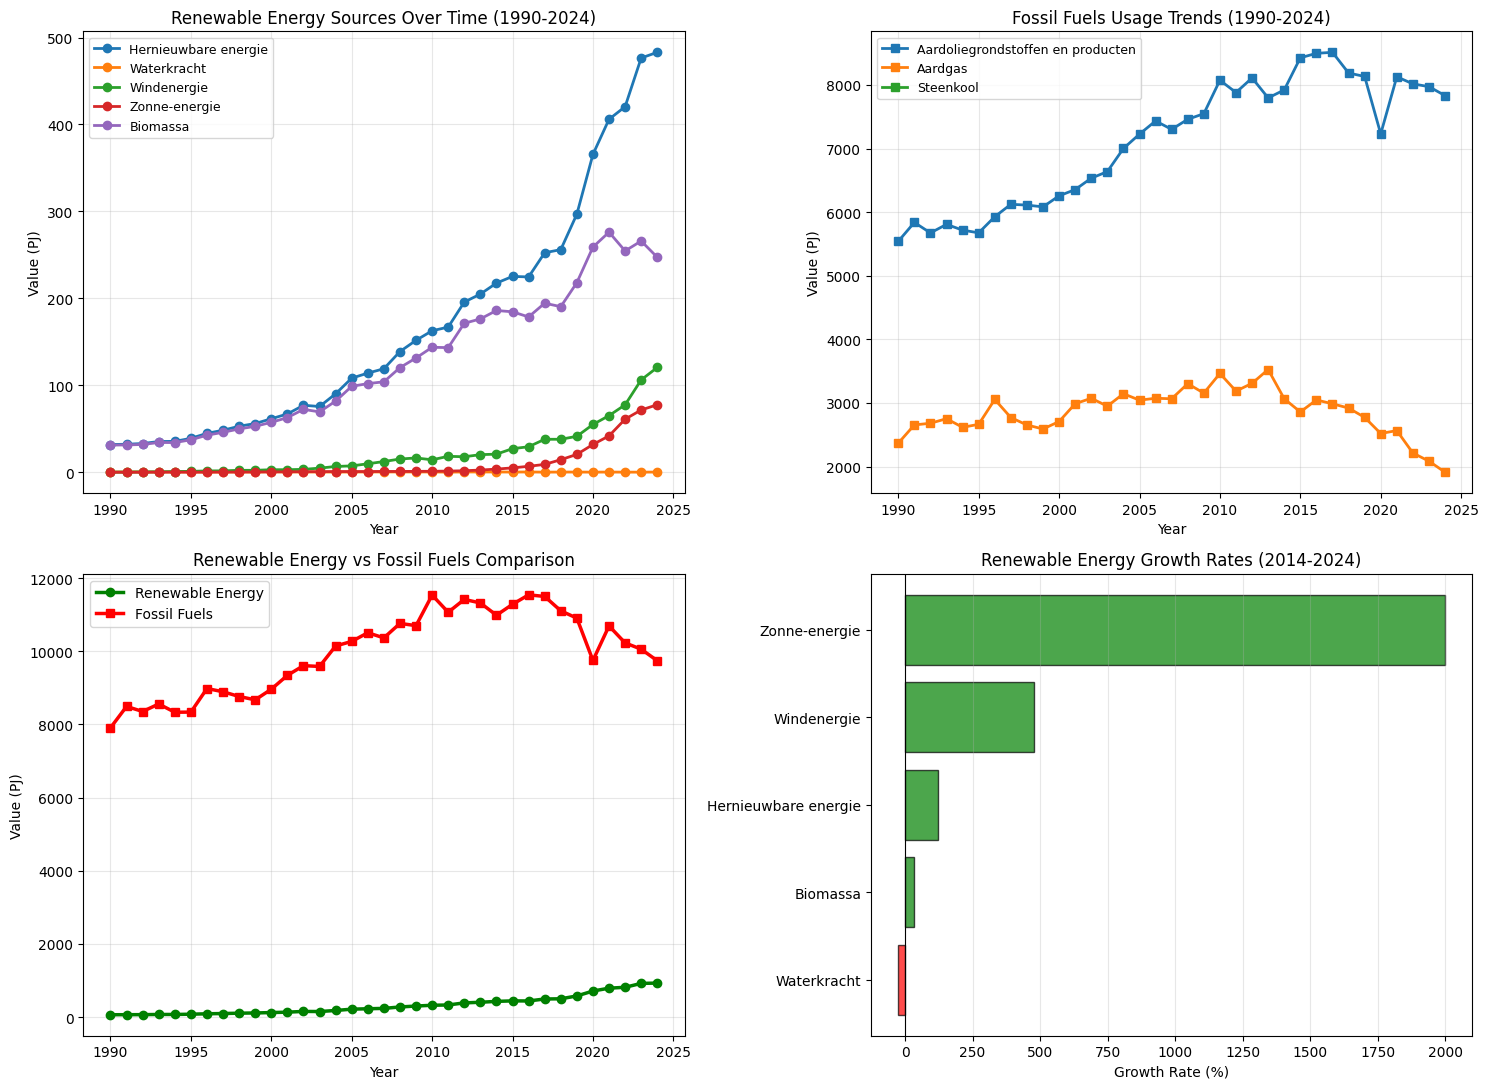

In [14]:
# Visualizations for guiding questions
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Chart 1: Renewable energy sources over time
ax1 = axes[0, 0]
renewable_sources = ['Hernieuwbare energie', 'Waterkracht', 'Windenergie', 'Zonne-energie', 'Biomassa']
for source in renewable_sources:
    source_data = df[df['Energiedrager'] == source].groupby('Jaar')['Waarde in PJ'].sum()
    ax1.plot(source_data.index, source_data.values, label=source, marker='o', linewidth=2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Value (PJ)')
ax1.set_title('Renewable Energy Sources Over Time (1990-2024)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Chart 2: Fossil fuels usage trends
ax2 = axes[0, 1]
fossil_fuels = ['Aardoliegrondstoffen en producten', 'Aardgas', 'Steenkool']
for fuel in fossil_fuels:
    fuel_data = df[df['Energiedrager'] == fuel].groupby('Jaar')['Waarde in PJ'].sum()
    ax2.plot(fuel_data.index, fuel_data.values, label=fuel, marker='s', linewidth=2)
ax2.set_xlabel('Year')
ax2.set_ylabel('Value (PJ)')
ax2.set_title('Fossil Fuels Usage Trends (1990-2024)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Chart 3: Renewable vs Fossil fuels comparison
ax3 = axes[1, 0]
renewable_total = df[df['Energiedrager'].isin(renewable_sources)].groupby('Jaar')['Waarde in PJ'].sum()
fossil_total = df[df['Energiedrager'].isin(fossil_fuels)].groupby('Jaar')['Waarde in PJ'].sum()
ax3.plot(renewable_total.index, renewable_total.values, label='Renewable Energy', marker='o', linewidth=2.5, color='green')
ax3.plot(fossil_total.index, fossil_total.values, label='Fossil Fuels', marker='s', linewidth=2.5, color='red')
ax3.set_xlabel('Year')
ax3.set_ylabel('Value (PJ)')
ax3.set_title('Renewable Energy vs Fossil Fuels Comparison')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# Chart 4: Growth rates comparison (past 10 years)
ax4 = axes[1, 1]
latest_year = df['Jaar'].max()
ten_years_ago = latest_year - 10

growth_data = []
for source in renewable_sources:
    source_data = df[df['Energiedrager'] == source]
    current = source_data[source_data['Jaar'] == latest_year]['Waarde in PJ'].sum()
    past = source_data[source_data['Jaar'] == ten_years_ago]['Waarde in PJ'].sum()
    if past > 0:
        growth_pct = ((current - past) / past) * 100
        growth_data.append((source, growth_pct))

growth_sources = [x[0] for x in sorted(growth_data, key=lambda x: x[1])]
growth_values = [x[1] for x in sorted(growth_data, key=lambda x: x[1])]
colors = ['green' if v > 0 else 'red' for v in growth_values]
ax4.barh(growth_sources, growth_values, color=colors, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Growth Rate (%)')
ax4.set_title(f'Renewable Energy Growth Rates ({ten_years_ago}-{latest_year})')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax4.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---

## 3. Data Preparation

### Cleaning and preprocessing


### Adjusting dataset


---

## 4. Modeling

### Model setup:


### Testing and performance


---

## 5. Evaluation

### Assessment against succes criteria


### Key findings and limitations**  *What did you learn? What are the limitations of this current model?
